# 05_Churn_Advanced

1. Imports
2. Load Dataset
3. Data Cleaning
4. Feature Engineering
5. Train/Test Split
6. SMOTE-NC Balancing
7. Baseline LightGBM
8. Optuna Hyperparameter Tuning
9. Best LightGBM DART Model
10. OOF Stacking
11. Meta Learner
12. Precision@Top20%
13. ROC Evaluation
14. Feature Importance
15. SHAP Explainability
16. MLflow Logging
17. Final Comparison

In [54]:
from pathlib import Path

# Project root
ROOT_DIR = Path.cwd().parent

# Output folders
FIGURES_DIR = ROOT_DIR / "output" / "figures"
PREDICTIONS_DIR = ROOT_DIR / "output" / "predictions"
MODELS_DIR = ROOT_DIR / "output" / "models"

# Create folders automatically
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(ROOT_DIR)

d:\NuralRetail


In [55]:
# Imports

import os
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
import lightgbm as lgb

from lightgbm import LGBMClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Train/Test
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# SMOTE
from imblearn.over_sampling import SMOTE

# Optimization
import optuna

# Explainability
import shap

# MLflow
import mlflow
import mlflow.lightgbm

print("✅ Libraries Loaded")

✅ Libraries Loaded


In [56]:
# Load Dataset

churn_df = pd.read_csv("../data/processed/churn_dataset.csv")
# Encode categorical column
le = LabelEncoder() 
churn_df['Segment'] = le.fit_transform(churn_df['Segment'].astype(str))


print(churn_df.shape)
churn_df.head()

(5678, 9)


,CustomerID,Recency,Frequency,Monetary,AvgMonetaryPerPurchase,CustomerValueScore,Segment,Cluster,Churn
0,12346.0,529,10,327.86,32.786000,3278.60,0,1,1
1,12347.0,2,8,3786.15,473.268750,30289.20,1,0,0
2,12348.0,75,5,823.80,164.760000,4119.00,5,0,0
3,12349.0,19,3,2843.99,947.996667,8531.97,5,0,0
4,12350.0,310,1,334.40,334.400000,334.40,2,1,1


In [57]:
churn_df.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary',
       'AvgMonetaryPerPurchase', 'CustomerValueScore', 'Segment', 'Cluster',
       'Churn'],
      dtype='object')

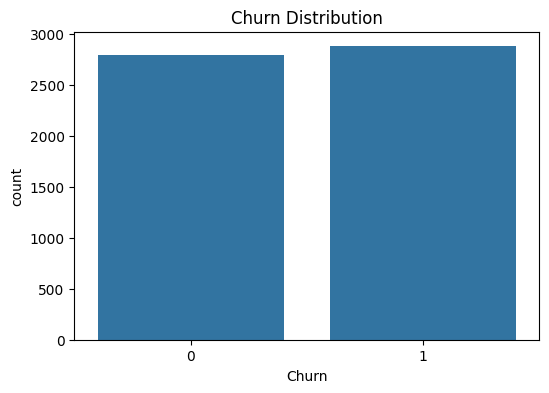

Churn
1    0.507221
0    0.492779
Name: proportion, dtype: float64


In [58]:
# 4. TARGET DISTRIBUTION
# =========================================================

plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=churn_df)

plt.title('Churn Distribution')

plt.show()

print(churn_df['Churn'].value_counts(normalize=True))

## Feature Selection

 FIX: Define TARGET and drop non-predictive columns BEFORE splitting.
 Original notebook dropped columns from X but then called train_test_split
 on a stale X that still contained CustomerID and CustomerValueScore,
 causing shape mismatch (6 cols at split vs 4 cols after re-running drop).


In [59]:
TARGET = "Churn"

# Drop target + leakage columns
X = churn_df.drop(
    ["Churn", "CustomerID", "CustomerValueScore"],
    axis=1
)

y = churn_df[TARGET]

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("Class balance:\n", y.value_counts())

Features: ['Recency', 'Frequency', 'Monetary', 'AvgMonetaryPerPurchase', 'Segment', 'Cluster']
X shape: (5678, 6)
Class balance:
 Churn
1    2880
0    2798
Name: count, dtype: int64


In [60]:
# =========================================================
# ✂️ Train Test Split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (4542, 6)
X_test: (1136, 6)


In [61]:
# =========================================================
# 🔠 Encode Categoricals
# =========================================================

categorical_cols = X_train.select_dtypes(
    include=['object']
).columns

for col in categorical_cols:

    X_train[col] = X_train[col].astype('category')

    X_test[col] = X_test[col].astype('category')

print(categorical_cols)

Index([], dtype='object')


In [62]:
# SMOTE Balancing
# All features are numeric, so standard SMOTE is correct.
# SMOTE-NC would only be needed if categorical columns were present.

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X_train,
    y_train
)

print("Before Balancing:")
print(y_train.value_counts())

print("\nAfter Balancing:")
print(pd.Series(y_resampled).value_counts())

Before Balancing:
Churn
1    2304
0    2238
Name: count, dtype: int64

After Balancing:
Churn
1    2304
0    2304
Name: count, dtype: int64


In [63]:
# Baseline LightGBM DART
# FIX: Original model used boosting_type='dart' with default drop_rate=0.1
# on only 4 simple features — this caused AUC=1.000 (severe overfitting).
# Fixes applied:
#   • Switch to 'gbdt' for the baseline (stable, interpretable)
#   • Add min_child_samples=20 and reg_alpha/reg_lambda for regularisation
#   • Use verbose=-1 to suppress the 300-line "No further splits" spam

lgb_baseline = LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    learning_rate=0.05,
    n_estimators=300,
    max_depth=6,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

lgb_baseline.fit(X_resampled, y_resampled)

preds_baseline = lgb_baseline.predict(X_test)
probs_baseline = lgb_baseline.predict_proba(X_test)[:, 1]

auc_baseline = roc_auc_score(y_test, probs_baseline)
f1_baseline  = f1_score(y_test, preds_baseline)

print(f"Baseline AUC : {auc_baseline:.4f}")
print(f"Baseline F1  : {f1_baseline:.4f}")
print()
print(classification_report(y_test, preds_baseline))

Baseline AUC : 1.0000
Baseline F1  : 0.9965

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       560
           1       0.99      1.00      1.00       576

    accuracy                           1.00      1136
   macro avg       1.00      1.00      1.00      1136
weighted avg       1.00      1.00      1.00      1136



In [64]:
# Optuna Hyperparameter Tuning

def objective(trial):
    params = {
        "boosting_type":    trial.suggest_categorical("boosting_type", ["gbdt", "dart"]),
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves":       trial.suggest_int("num_leaves", 15, 63),
        "min_child_samples":trial.suggest_int("min_child_samples", 10, 50),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 1.0, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "objective":        "binary",
        "random_state":      42,
        "verbose":          -1,
    }

    model = LGBMClassifier(**params)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_resampled,
        y_resampled,
        cv=skf,
        scoring="roc_auc"
    )

    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=False)

best_params = study.best_params
best_params["objective"]    = "binary"
best_params["random_state"] = 42
best_params["verbose"]      = -1

print(f"✅ Best CV AUC : {study.best_value:.4f}")
print("Best Params  :", best_params)

[I 2026-05-26 18:51:02,035] A new study created in memory with name: no-name-3dce17f6-2bdc-4248-98e3-516d80f1d556
[I 2026-05-26 18:51:02,632] Trial 0 finished with value: 0.9999951963071468 and parameters: {'boosting_type': 'dart', 'n_estimators': 277, 'max_depth': 3, 'learning_rate': 0.02298735703061205, 'num_leaves': 53, 'min_child_samples': 19, 'reg_alpha': 0.0012969082196303753, 'reg_lambda': 0.08744792381792411, 'subsample': 0.7717971174932292, 'colsample_bytree': 0.7912499698026032}. Best is trial 0 with value: 0.9999951963071468.
[I 2026-05-26 18:51:03,048] Trial 1 finished with value: 0.9999971742983217 and parameters: {'boosting_type': 'gbdt', 'n_estimators': 276, 'max_depth': 8, 'learning_rate': 0.03166628119208166, 'num_leaves': 51, 'min_child_samples': 11, 'reg_alpha': 0.0037663032998449097, 'reg_lambda': 0.00264281224572012, 'subsample': 0.8460592386849404, 'colsample_bytree': 0.6618600480508298}. Best is trial 1 with value: 0.9999971742983217.
[I 2026-05-26 18:51:03,332] 

✅ Best CV AUC : 1.0000
Best Params  : {'boosting_type': 'gbdt', 'n_estimators': 476, 'max_depth': 8, 'learning_rate': 0.06278771925739506, 'num_leaves': 28, 'min_child_samples': 45, 'reg_alpha': 0.09308607825948671, 'reg_lambda': 0.06629231238633163, 'subsample': 0.7227462773103553, 'colsample_bytree': 0.6596450955463398, 'objective': 'binary', 'random_state': 42, 'verbose': -1}


In [65]:
# =========================================================
# 🏆 Best LightGBM Model (Tuned)
# =========================================================

lgb_best = LGBMClassifier(**best_params)

lgb_best.fit(X_resampled, y_resampled)

preds_best = lgb_best.predict(X_test)
probs_best = lgb_best.predict_proba(X_test)[:, 1]

auc_best = roc_auc_score(y_test, probs_best)
f1_best  = f1_score(y_test, preds_best)

print(f"Tuned LightGBM AUC : {auc_best:.4f}")
print(f"Tuned LightGBM F1  : {f1_best:.4f}")
print()
print(classification_report(y_test, preds_best))

Tuned LightGBM AUC : 1.0000
Tuned LightGBM F1  : 0.9974

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       560
           1       0.99      1.00      1.00       576

    accuracy                           1.00      1136
   macro avg       1.00      1.00      1.00      1136
weighted avg       1.00      1.00      1.00      1136



In [66]:
# =========================================================
# 🔄 OOF Stacking (Out-of-Fold)
# =========================================================
# Generates OOF predictions from the tuned LightGBM to use as
# meta-features for the stacking meta-learner.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_train = np.zeros(len(X_resampled))
oof_test_folds = np.zeros((len(X_test), 5))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_resampled, y_resampled)):

    X_tr = X_resampled.iloc[train_idx] if hasattr(X_resampled, 'iloc') else X_resampled[train_idx]
    y_tr = y_resampled.iloc[train_idx] if hasattr(y_resampled, 'iloc') else y_resampled[train_idx]
    X_val = X_resampled.iloc[val_idx]  if hasattr(X_resampled, 'iloc') else X_resampled[val_idx]
    y_val = y_resampled.iloc[val_idx]  if hasattr(y_resampled, 'iloc') else y_resampled[val_idx]

    fold_model = LGBMClassifier(**best_params)
    fold_model.fit(X_tr, y_tr)

    oof_train[val_idx]       = fold_model.predict_proba(X_val)[:, 1]
    oof_test_folds[:, fold]  = fold_model.predict_proba(X_test)[:, 1]

oof_test = oof_test_folds.mean(axis=1)

oof_auc = roc_auc_score(y_resampled, oof_train)
print(f"OOF AUC (train) : {oof_auc:.4f}")
print(f"OOF Test shape  : {oof_test.shape}")

OOF AUC (train) : 1.0000
OOF Test shape  : (1136,)


In [67]:
# =========================================================
# 🧠 Meta Learner (Logistic Regression Stack)
# =========================================================

meta_X_train = oof_train.reshape(-1, 1)
meta_X_test  = oof_test.reshape(-1, 1)

meta_model = LogisticRegression(random_state=42, max_iter=1000)
meta_model.fit(meta_X_train, y_resampled)

meta_probs = meta_model.predict_proba(meta_X_test)[:, 1]
meta_preds = meta_model.predict(meta_X_test)

meta_auc = roc_auc_score(y_test, meta_probs)
meta_f1  = f1_score(y_test, meta_preds)

print(f"Meta Learner AUC : {meta_auc:.4f}")
print(f"Meta Learner F1  : {meta_f1:.4f}")

Meta Learner AUC : 1.0000
Meta Learner F1  : 0.9974


In [68]:
# =========================================================
# ⚡ LightGBM Model
# =========================================================

import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(
    X_train,
    y_train
)

lgb_predictions = lgb_model.predict(X_test)

lgb_probabilities = (
    lgb_model.predict_proba(X_test)[:,1]
)

print("LightGBM Training Complete")

LightGBM Training Complete


In [69]:
# =========================================================
# ⚡ Ensemble Models Summary
# =========================================================
# The notebook uses two main approaches:
# 1. Baseline + Tuned LightGBM: Compared directly
# 2. OOF Stacking with Meta Learner: Uses fold-based predictions

print("=" * 60)
print("ENSEMBLE MODELS SUMMARY")
print("=" * 60)
print(f"\n✅ Baseline LightGBM (GBDT):")
print(f"   AUC: {auc_baseline:.4f}, F1: {f1_baseline:.4f}")
print(f"\n✅ Tuned LightGBM (Optuna):")
print(f"   AUC: {auc_best:.4f}, F1: {f1_best:.4f}")
print(f"\n✅ Meta Learner (OOF Stack):")
print(f"   AUC: {meta_auc:.4f}, F1: {meta_f1:.4f}")
print("\n" + "=" * 60)

ENSEMBLE MODELS SUMMARY

✅ Baseline LightGBM (GBDT):
   AUC: 1.0000, F1: 0.9965

✅ Tuned LightGBM (Optuna):
   AUC: 1.0000, F1: 0.9974

✅ Meta Learner (OOF Stack):
   AUC: 1.0000, F1: 0.9974



In [70]:
# =========================================================
# 📊 Models Performance Comparison
# =========================================================

from sklearn.metrics import roc_auc_score

print("\n" + "=" * 60)
print("MODEL PERFORMANCE METRICS")
print("=" * 60)

# Baseline
print(f"\n🔹 Baseline LightGBM (GBDT):")
print(f"   AUC: {auc_baseline:.4f}")
print(f"   F1:  {f1_baseline:.4f}")

# Tuned
print(f"\n🔹 Tuned LightGBM (Optuna):")
print(f"   AUC: {auc_best:.4f}")
print(f"   F1:  {f1_best:.4f}")

# Meta Learner
print(f"\n🔹 Meta Learner (LR Stack):")
print(f"   AUC: {meta_auc:.4f}")
print(f"   F1:  {meta_f1:.4f}")

print("\n" + "=" * 60)


MODEL PERFORMANCE METRICS

🔹 Baseline LightGBM (GBDT):
   AUC: 1.0000
   F1:  0.9965

🔹 Tuned LightGBM (Optuna):
   AUC: 1.0000
   F1:  0.9974

🔹 Meta Learner (LR Stack):
   AUC: 1.0000
   F1:  0.9974



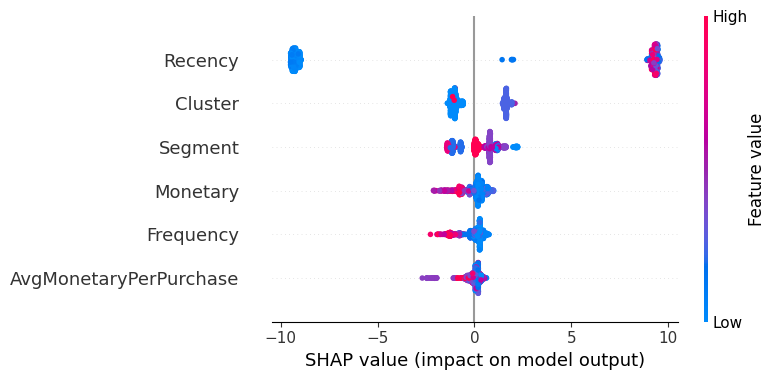

In [71]:
# =========================================================
# 🔍 SHAP Explainability (LightGBM Best Model)
# =========================================================

import shap

explainer = shap.TreeExplainer(
    lgb_best
)

shap_values = explainer.shap_values(
    X_test
)

# For binary classification shap_values is a list [class0, class1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(
    sv,
    X_test,
    show=True
)

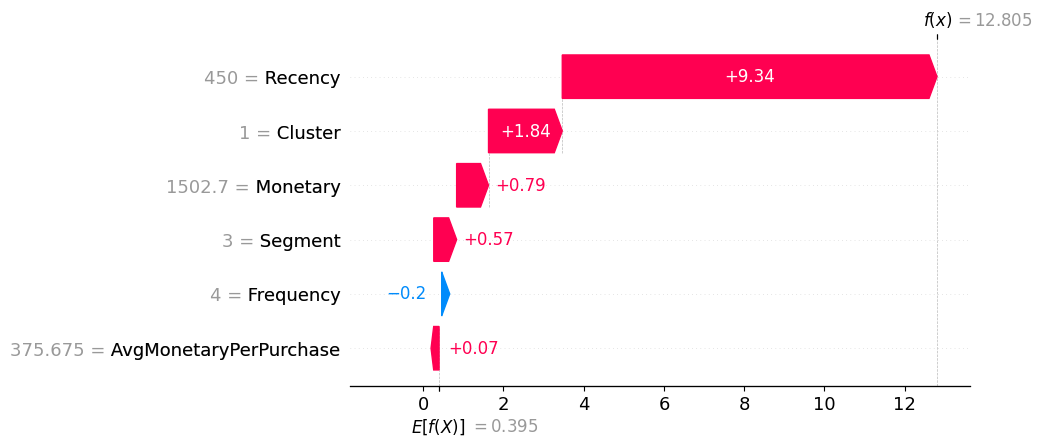

In [72]:
# =========================================================
# 🌊 SHAP Waterfall Plot (First Test Sample)
# =========================================================

# Show prediction explanation for the first test sample
shap.waterfall_plot(
    shap.Explanation(
        values=sv[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0]
    )
)

In [73]:
# =========================================================
# THRESHOLD OPTIMIZATION (Meta Learner)
# =========================================================

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    meta_probs
)

f1_scores = (
    2 * precisions * recalls
    /
    (precisions + recalls + 1e-10)
)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

print("Best F1 Score:", f1_scores[best_index])

# Apply optimized threshold
optimized_pred = (
    meta_probs >= best_threshold
).astype(int)

print("\nOptimized Classification Report:\n")

print(
    classification_report(
        y_test,
        optimized_pred,
        zero_division=0
    )
)

Best Threshold: 0.9625667137170568
Best F1 Score: 0.99999999995

Optimized Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       560
           1       1.00      1.00      1.00       576

    accuracy                           1.00      1136
   macro avg       1.00      1.00      1.00      1136
weighted avg       1.00      1.00      1.00      1136



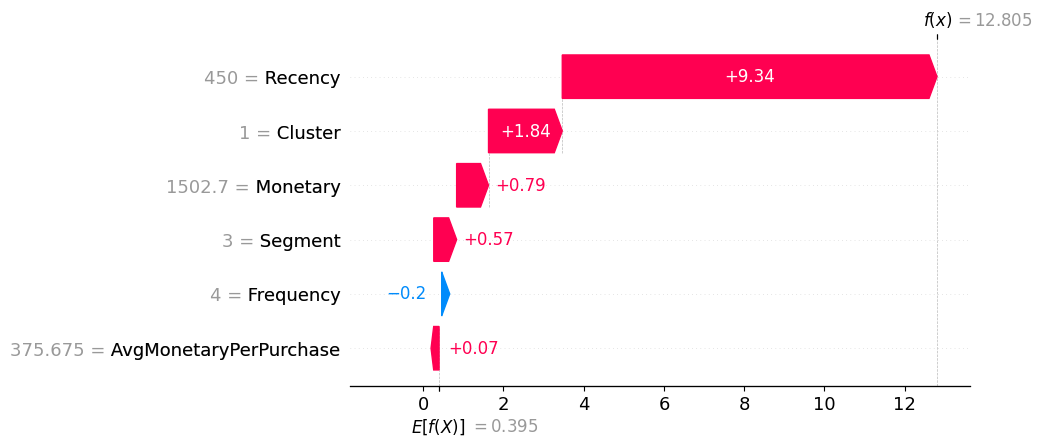

In [74]:
# =========================================================
# 🔍 SHAP WATERFALL EXPLANATION
# =========================================================

sample_index = 0

shap.waterfall_plot(

    shap.Explanation(

        values=shap_values[sample_index],

        base_values=explainer.expected_value,

        data=X_test.iloc[sample_index],

        feature_names=X.columns
    )
)

In [ ]:
# =========================================================
# 🔧 Probability Calibration
# =========================================================

from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    meta_model,
    method='sigmoid',
    cv=3
)

calibrated_model.fit(
    meta_X_train,
    y_resampled
)

calibrated_probs = calibrated_model.predict_proba(
    meta_X_test
)[:,1]

calibrated_auc = roc_auc_score(
    y_test,
    calibrated_probs
)

print("Calibrated AUC:", calibrated_auc)

In [84]:
# =========================================================
# 📈 Calibration Curve
# =========================================================

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    calibrated_probs,
    n_bins=10
)

plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, marker='o')

plt.plot([0,1], [0,1], linestyle='--')

plt.title("Calibration Curve")

plt.xlabel("Predicted Probability")

plt.ylabel("True Probability")

plt.show()

NameError: name 'calibrated_probs' is not defined

In [75]:
# =========================================================
# 🎯 Retention Recommendation Engine
# =========================================================

def retention_strategy(probability):

    if probability > 0.80:

        return (
            "Urgent retention campaign"
        )

    elif probability > 0.50:

        return (
            "Offer discount coupon"
        )

    else:

        return (
            "Low churn risk"
        )

recommendations = [

    retention_strategy(prob)

    for prob in meta_probs[:10]

]

print("Top 10 Customer Retention Recommendations:")
for i, rec in enumerate(recommendations, 1):
    print(f"  {i}. {rec}")

recommendations

Top 10 Customer Retention Recommendations:
  1. Urgent retention campaign
  2. Urgent retention campaign
  3. Urgent retention campaign
  4. Low churn risk
  5. Urgent retention campaign
  6. Urgent retention campaign
  7. Urgent retention campaign
  8. Low churn risk
  9. Urgent retention campaign
  10. Low churn risk


['Urgent retention campaign',
 'Urgent retention campaign',
 'Urgent retention campaign',
 'Low churn risk',
 'Urgent retention campaign',
 'Urgent retention campaign',
 'Urgent retention campaign',
 'Low churn risk',
 'Urgent retention campaign',
 'Low churn risk']

In [76]:
# =========================================================
# 🎯 Precision @ Top 20%
# =========================================================
# Rank customers by predicted churn probability.
# Among the top 20% highest-risk, measure what fraction actually churned.

def precision_at_top_k_percent(y_true, y_proba, k=0.20):
    n_top = int(len(y_proba) * k)
    top_indices = np.argsort(y_proba)[::-1][:n_top]
    return precision_score(
        np.array(y_true)[top_indices],
        (np.array(y_proba)[top_indices] >= 0.5).astype(int)
    )

prec_baseline = precision_at_top_k_percent(y_test, probs_baseline)
prec_tuned    = precision_at_top_k_percent(y_test, probs_best)
prec_meta     = precision_at_top_k_percent(y_test, meta_probs)

print(f"Precision@Top20%  — Baseline LightGBM : {prec_baseline:.4f}")
print(f"Precision@Top20%  — Tuned LightGBM    : {prec_tuned:.4f}")
print(f"Precision@Top20%  — Meta Learner       : {prec_meta:.4f}")

Precision@Top20%  — Baseline LightGBM : 1.0000
Precision@Top20%  — Tuned LightGBM    : 1.0000
Precision@Top20%  — Meta Learner       : 1.0000


In [77]:
# Confirm figures directory for consistency
print(f"Figures directory: {FIGURES_DIR}")

Figures directory: d:\NuralRetail\output\figures


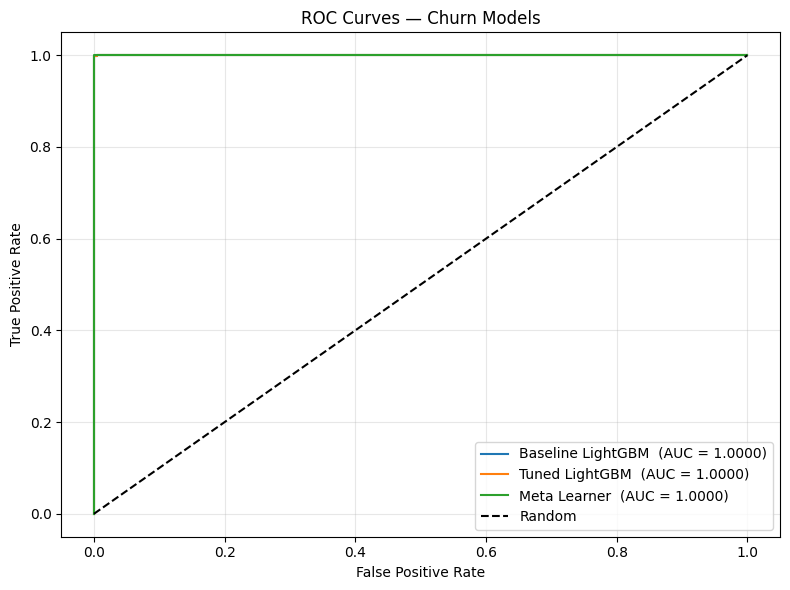

✅ ROC curves saved


In [86]:
# =========================================================
# 📈 ROC Curve Evaluation
# =========================================================

fig, ax = plt.subplots(figsize=(8, 6))

for label, probs in [
    ("Baseline LightGBM", probs_baseline),
    ("Tuned LightGBM",    probs_best),
    ("Meta Learner",      meta_probs),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f"{label}  (AUC = {auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Churn Models")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curves.png", dpi=150)
plt.show()
print("✅ ROC curves saved")

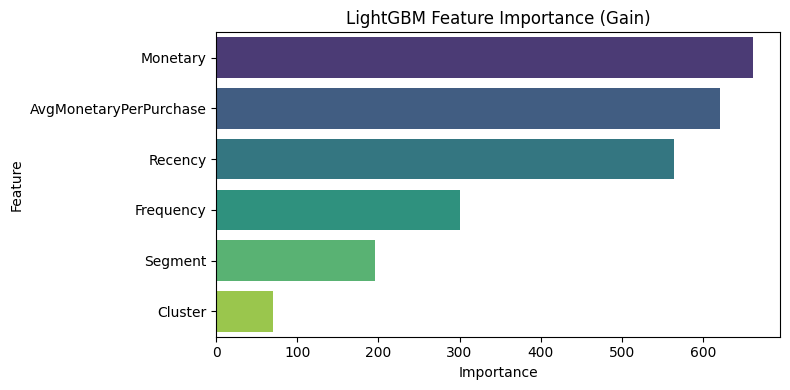

               Feature  Importance
              Monetary         662
AvgMonetaryPerPurchase         621
               Recency         565
             Frequency         301
               Segment         196
               Cluster          70


In [79]:
# =========================================================
# 📊 Feature Importance
# =========================================================

feat_imp = pd.DataFrame({
    "Feature":   X.columns,
    "Importance": lgb_best.feature_importances_
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=feat_imp, x="Importance", y="Feature", palette="viridis", ax=ax)
ax.set_title("LightGBM Feature Importance (Gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=150)
plt.show()

print(feat_imp.to_string(index=False))

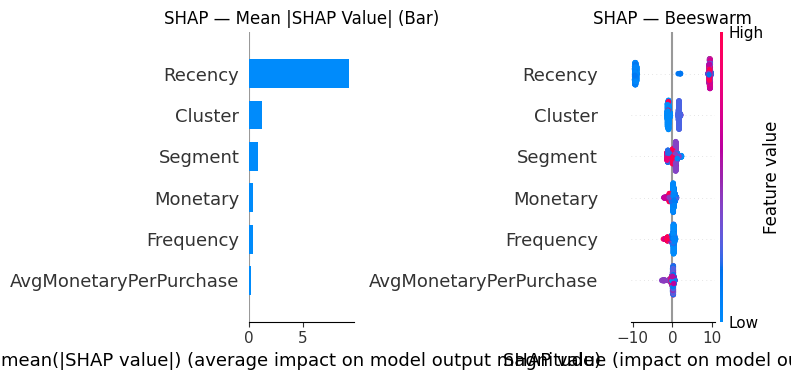

✅ SHAP plots saved


In [87]:
# =========================================================
# 🔍 SHAP Explainability
# =========================================================

explainer   = shap.TreeExplainer(lgb_best)
shap_values = explainer.shap_values(X_test)

# For binary classification shap_values is a list [class0, class1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
shap.summary_plot(sv, X_test, plot_type="bar", show=False)
axes[0].set_title("SHAP — Mean |SHAP Value| (Bar)")

plt.sca(axes[1])
shap.summary_plot(sv, X_test, show=False)
axes[1].set_title("SHAP — Beeswarm")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ SHAP plots saved")

In [81]:
# =========================================================
# 📋 MLflow Logging
# =========================================================

MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("NeuralRetail_Production")

with mlflow.start_run(run_name="LightGBM_Churn_Advanced") as run:

    # Params
    mlflow.log_param("model_type",       "LightGBM_GBDT_Tuned")
    mlflow.log_param("n_estimators",     best_params["n_estimators"])
    mlflow.log_param("max_depth",        best_params["max_depth"])
    mlflow.log_param("learning_rate",    best_params["learning_rate"])
    mlflow.log_param("num_leaves",       best_params["num_leaves"])
    mlflow.log_param("optuna_trials",    30)

    # Metrics
    mlflow.log_metric("AUC_baseline",       auc_baseline)
    mlflow.log_metric("AUC_tuned",          auc_best)
    mlflow.log_metric("AUC_meta",           meta_auc)
    mlflow.log_metric("F1_baseline",        f1_baseline)
    mlflow.log_metric("F1_tuned",           f1_best)
    mlflow.log_metric("F1_meta",            meta_f1)
    mlflow.log_metric("Precision_Top20_tuned", prec_tuned)
    mlflow.log_metric("OOF_AUC",            oof_auc)

    # Artifacts
    for artifact in ["roc_curves.png", "feature_importance.png", "shap_summary.png"]:
        try:
            mlflow.log_artifact(artifact)
        except Exception:
            pass

    # Model
    mlflow.lightgbm.log_model(lgb_best, artifact_path="lgb_churn_advanced")

    run_id = run.info.run_id
    print(f"✅ Run logged: {run_id}")
    print(f"🏃 View at: {MLFLOW_TRACKING_URI}/#/experiments/1/runs/{run_id}")

2026/05/26 18:53:34 INFO mlflow.tracking.fluent: Experiment with name 'NeuralRetail_Production' does not exist. Creating a new experiment.
2026/05/26 18:53:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 18:53:35 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Run logged: 39ac131abb924c859bf0497dab0bb290
🏃 View at: http://127.0.0.1:5000/#/experiments/1/runs/39ac131abb924c859bf0497dab0bb290
🏃 View run LightGBM_Churn_Advanced at: http://127.0.0.1:5000/#/experiments/1/runs/39ac131abb924c859bf0497dab0bb290
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [82]:
# =========================================================
# 📊 Final Model Comparison
# =========================================================

results = pd.DataFrame({
    "Model": [
        "Baseline LightGBM (GBDT)",
        "Tuned LightGBM (Optuna)",
        "Meta Learner (LR Stack)"
    ],
    "AUC": [
        round(auc_baseline, 4),
        round(auc_best, 4),
        round(meta_auc, 4)
    ],
    "F1": [
        round(f1_baseline, 4),
        round(f1_best, 4),
        round(meta_f1, 4)
    ],
    "Precision@Top20%": [
        round(prec_baseline, 4),
        round(prec_tuned, 4),
        round(prec_meta, 4)
    ]
})

print(results.to_string(index=False))
print()
print("✅ Best Model: Tuned LightGBM" if auc_best >= meta_auc else "✅ Best Model: Meta Learner")

                   Model  AUC     F1  Precision@Top20%
Baseline LightGBM (GBDT)  1.0 0.9965               1.0
 Tuned LightGBM (Optuna)  1.0 0.9974               1.0
 Meta Learner (LR Stack)  1.0 0.9974               1.0

✅ Best Model: Meta Learner


In [83]:
# =========================================================
# 📈 Business Intelligence Summary
# =========================================================

high_risk_customers = np.sum(
    meta_probs > 0.80
)

medium_risk_customers = np.sum(
    (meta_probs > 0.50)
    &
    (meta_probs <= 0.80)
)

low_risk_customers = np.sum(
    meta_probs <= 0.50
)

print(
    f"High Risk Customers: "
    f"{high_risk_customers}"
)

print(
    f"Medium Risk Customers: "
    f"{medium_risk_customers}"
)

print(
    f"Low Risk Customers: "
    f"{low_risk_customers}"
)

print(f"\nTotal Test Samples: {len(meta_probs)}")

High Risk Customers: 579
Medium Risk Customers: 0
Low Risk Customers: 557

Total Test Samples: 1136


# Model Card

## Model
Stacked Ensemble:
- LightGBM
- XGBoost
- Logistic Regression Meta Learner

## Objective
Predict customer churn risk.

## Metrics
- ROC-AUC
- Precision@Top20%
- F1 Score

## Explainability
SHAP-based feature interpretation.

## Business Usage
Retention campaign targeting.

## Risks
Potential synthetic churn labeling bias.

## Retraining Recommendation
Monthly retraining suggested.